# Leuphana Universität Lüneburg - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Leuphana Universität Lüneburg' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/02w2y2t16' -- 'Leuphana Universität Lüneburg'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Leuphana Universität Lüneburg,"Institute of Sustainable Chemistry, Leuphana U...",https://openalex.org/W4311372139
1,not assigned,Leuphana Universität Lüneburg,"Institute of Product and Process Innovation, L...",https://openalex.org/W4295021562
2,not assigned,Leuphana Universität Lüneburg,"Sustainable Chemistry (Resource Efficiency), I...",https://openalex.org/W4306292672
3,not assigned,Leuphana Universität Lüneburg,"Institute of Product and Process Innovation, L...",https://openalex.org/W4313379324
4,not assigned,Leuphana Universität Lüneburg,"Leuphana University, Faculty of Sustainability...",https://openalex.org/W4285194449


In [225]:
MAPPING_DICT = {
    'DFG-Kollegforschergruppe Medienkulturen der Computersimulation (mecs)': ['media cultures', 'mecs,', 'institute for advanced stud(y|ies)'],
    'Fakultät Bildung': ['sport', 'psychology', 'theolog(ie|y|ical)', '(?<!teacher\s)education', 'english', 'dida(c|k)ti(c|k)', 'fakultät bildung', 
                         'institut für psychologie', 'institute of arts', 'methodology and evaluation research',
                         'bildungswissenschaft', 'social work', 'sozialarbeit', 'digital teaching', 'schulpädagogik', 'mathematics', 'social sciences'
                        ],
    'Fakultät Kulturwissenschaften': ['(isco)', 'sociology', 'philosophy', 'kulturorganisation', 'culture and aesthetics', 'geschichtswissenschaft',
                                      'ästhetik', 'kunstwissenschaft', 'cultural management', 'icam,', 'wissensgeschichte', 'faculty of humanities'
                                     ],
    'Fakultät Management und Technologie': ['management (&|and|und|&amp;) organi(z|s)ation', 'department of (entrepreneurship|economics)',
                                            'process', 'production', 'information', 'accounting', 'fakultät management & technologie',
                                            'explainability', 'produktionstechnik', 'performance', 'product technology',
                                            'banking', 'innovation', 'business and economics', '(faculty|school|institute) of management (and|&amp;|&) technology',
                                            'department of management', 'wirtschaftsinformatik', 'machine learning', 'digital transformation',
                                            'administration', 'control and drive systems'
                                           ],
    'Fakultät Nachhaltigkeit': ['sustainability', 'ecolog(y|ical|ía)', 'chemistry', 'nachhaltigkeit', 'chemie', 'environmental communication',
                                'energy law', 'ethics', 'sustainable development', 'umweltrecht', 'nachhaltige entwicklung', 'umweltkommunikation',
                                'insugo,', 'isec,', 'energy economics', 'social(-|‑|–|\s)ecological', '(sesi)', 'gesundheitspsychologie'
                               ],
    'Fakultät Staatswissenschaften': ['politikwissenschaft', 'institute (of|for) economics', 'political science', 'volkswirtschaft(s)?lehre',
                                      'political culture', 'public affairs', 'chair of finance', '(arbeits|seevölker)recht', 'rechtswissenschaft',
                                      '(öffentliches|bürgerliches) recht'
                                     ],
    'Forschungszentrum Futures of Ecosystem Services (FuturES)': ['futures of ecosystem'],
    'Methodenzentrum': ['cent(er|re) (of|for) methods', 'methodology center'],
    'Research Center for Entrepreneurship (RCE)': ['evidence-based entrepreneurship'],
    'Zentraleinrichtung Sprachenzentrum': ['sprachenzentrum'],
    'Zentrum Digitale Kulturen (CDC)': ['Digital Cultures'],
    'Zentrum für Angewandte Gesundheitswissenschaften (ZAG)': ['health', 'gesundheitswissenschaften'],
    'Zentrum für Demokratieforschung (ZDEMO)': ['demokratieforschung', 'democracy'],
    'Zentrum für Empirische Forschung zu Sprache und Bildung (ERLE)': ['empirische forschung zu sprache', 'empirical research on language'],
    'Zukunftszentrum Lehrerbildung': ['lehr(er|kräfte)bildung', 'competencies for digitally-enhanced', 'cent(er|re) (of|for) teacher education']
}

In [226]:
with open('./mapping_tables_fak/leuphana.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [227]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [228]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [229]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,Fakultät Nachhaltigkeit,Leuphana Universität Lüneburg,"Institute of Sustainable Chemistry, Leuphana U...",https://openalex.org/W4311372139
1,Fakultät Management und Technologie,Leuphana Universität Lüneburg,"Institute of Product and Process Innovation, L...",https://openalex.org/W4295021562
2,Fakultät Nachhaltigkeit,Leuphana Universität Lüneburg,"Sustainable Chemistry (Resource Efficiency), I...",https://openalex.org/W4306292672
3,Fakultät Management und Technologie,Leuphana Universität Lüneburg,"Institute of Product and Process Innovation, L...",https://openalex.org/W4313379324
4,Fakultät Nachhaltigkeit,Leuphana Universität Lüneburg,"Leuphana University, Faculty of Sustainability...",https://openalex.org/W4285194449
...,...,...,...,...
4028,None,Leuphana Universität Lüneburg,"Leuphana Universität Lüneburg, Lüneburg, Deuts...",https://openalex.org/W3091254096
4029,None,Leuphana Universität Lüneburg,"Leuphana Universität Lüneburg, Lüneburg, Deuts...",https://openalex.org/W3016179264
4030,None,Leuphana Universität Lüneburg,"Leuphana Universität Lüneburg, Lüneburg, Deuts...",https://openalex.org/W3009803992
4031,None,Leuphana Universität Lüneburg,"Leuphana Universität Lüneburg, Lüneburg, Deuts...",https://openalex.org/W3025378248


In [230]:
df_with_inst[(df_with_inst.fak_name.isnull()) & df_with_inst.raw_affiliation_string.str.contains('leuphana', case=False, regex=False)].raw_affiliation_string.unique()

array(['Leuphana University Lüneburg, Universitätsallee 1, 21335, Lüneburg, Germany',
       'Leuphana University Lüneburg, Universitätsallee 1, C6.227, 21335, Lüneburg, Germany',
       'Leuphana University Lüneburg, Germany,',
       'ISNI: 0000000105503270 Bochum University of Applied Sciences and ISNI: 0000000091306144 Leuphana University Lüneburg',
       'Leuphana University of Lüneburg Lüneburg Germany',
       'Leuphana University of Lueneburg , Lueneburg, Niedersachsen , Germany',
       'Leuphana University Lueneburg, Lüneburg , Niedersachsen , Germany',
       'ISNI: 0000000417602008 Shanxi University and ISNI: 0000000091306144 Leuphana University of Lüneburg',
       'Leuphana University Lueneburg, Lueneburg, Germany',
       'Leuphana University Lueneburg  Lueneburg Germany',
       'Leuphana University Lüneburg  Lüneburg Germany',
       'Leuphana Universität Lüneburg Germany',
       'Leuphana Universität Lüneburg, Universitätsallee 1 , 21335 Lüneburg ; Germany',
       

In [231]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,DFG-Kollegforschergruppe Medienkulturen der Co...,14
1,Fakultät Bildung,554
2,Fakultät Kulturwissenschaften,60
3,Fakultät Management und Technologie,766
4,Fakultät Nachhaltigkeit,1171
5,Fakultät Staatswissenschaften,95
6,Methodenzentrum,12
7,Zentrum Digitale Kulturen (CDC),4
8,Zentrum für Angewandte Gesundheitswissenschaft...,132
9,Zentrum für Demokratieforschung (ZDEMO),26


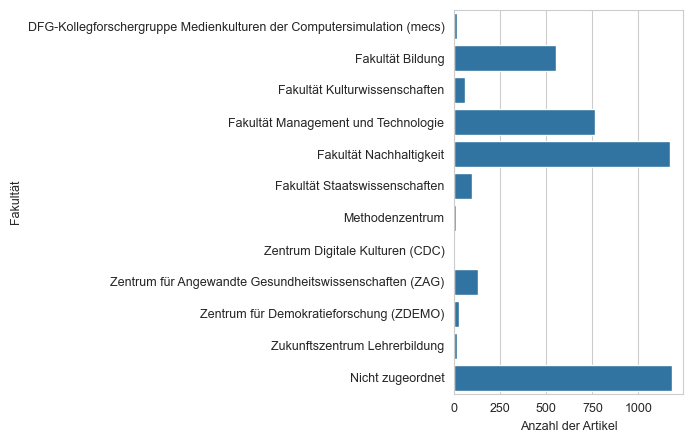

In [232]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [233]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.7066699727250186

In [254]:
MAPPING_DICT_DEPT = {
    'Fakultät Bildung': {
        'Arbeitseinheit Wirtschaftspädagogik': ['wirtschaftspädagogik'],
        'Institut für Bewegung, Sport und Gesundheit (IBSG)': ['sport'],
        'Institut für Bildungswissenschaft (IBIWI)': ['bildungswissenschaft', 'institute of educational science', 'schulpädagogik'],
        'Institut für Deutsche Sprache und Literatur und ihre Didaktik': ['deutsche sprache'],
        'Institut für Ethik und Theologie (IET)': ['theolog(ie|y)'],
        'Institut für Kunst, Musik und ihre Vermittlung (IKMV)': ['musi(k|c)', 'institute of arts'],
        'Institut für Mathematik und ihre Didaktik (IMD)': ['mathemati(k|cs)'],
        'Institut für Psychologie (IFP)': ['(institut(e)?|department) (of|für) psycholog(ie|y)', 'health psychology'],
        'Institut für Sozialarbeit und Sozialpädagogik (IFSP)': ['sozialarbeit', 'social work'],
        'Institute for Sustainability Education and Psychology (ISEP)': ['sustainability'],
        'Institute of English Studies (IES)': ['english studies'],
    },
    'Fakultät Kulturwissenschaften': {
        'Institut für Geschichtswissenschaft und Literarische Kulturen': ['geschichtswissenschaft'],
        'Institut für Kultur und Ästhetik Digitaler Medien': ['aesthetics', 'ästhetik', 'icam,', 'cultural management'],
        'Institut für Philosophie und Kunstwissenschaft (IPK)': ['philosoph(ie|y)'],
        'Institut für Soziologie und Kulturorganisation (ISKO)': ['so(z|c)iolog(ie|y)'],
        'Institut für Stadt- und Kulturraumforschung (IFSK)': ['kulturraumforschung'],
    },
    'Fakultät Management und Technologie': {
        'Institut Auditing and Tax': ['accounting'],
        'Institut für Bank-, Finanz- und Gründungsmanagement': ['banking'],
        'Institut für Experimentelle Wirtschaftspsychologie (Luenelab)': ['wirtschaftspsychologie'],
        'Institut für Management und Organisation (IMO)': ['pro(z|c)ess(\s)?innovation', 'management (and|&|und) organi(s|z)ation'],
        'Institut für Marketing (IFM)': ['marketing'],
        'Institut für Performance Management (IPM)': ['performance management'],
        'Institut für Produktionstechnik und -systeme (IPTS)': ['product(ion)?(\s)?techn(ique|ology)', 'produktionstechnik', 'sensor technology', 'drive systems'],
        'Institut für Wirtschaftsinformatik (IIS)': ['institute (of|for) information systems', 'wirtschaftsinformatik', 'machine learning', 'data science',
                                                     'ai and explainability', 'information science', 'artificial intelligence'
                                                    ],
        #'Institut für Wissens- und Informationsmanagement (IWI)': [],
    },
    'Fakultät Nachhaltigkeit': {
        'Centre for Sustainability Management (CSM)': ['centre for sustainability management'],
        'Institut für Ethik und transdisziplinäre Nachhaltigkeitsforschung (IETSR)': ['transdis(z|c)iplin(äre|ary)'],
        'Institut für integrative Studien (infis)': ['sustainable development and learning', 'integrative studie(n|s)'],
        'Institut für Nachhaltige Chemie und Umweltchemie (INUC)': ['(sustainable|environmental) chemistry', 'nachhaltige chemie'],
        'Institut für Nachhaltigkeitssteuerung (INSUGO)': ['sustainability governance', 'public law', 'research group governance', 'öffentliches recht',
                                                           'insugo,', 'nachhaltigkeitssteuerung'
                                                          ],
        'Institut für Umweltkommunikation (INFU)': ['(environmental|sustainability) communication', 'umweltkommunikation'],
        'Institut für Ökologie (IE)': ['ecolog(y|ía)', 'ökologie'],
        'Institute of Sustainability Psychology (ISP)': ['psycholog(ie|y)'],
        #'Professur für Nachhaltigkeitsforschung': [],
        'Social-Ecological Systems Institute (SESI)': ['soci(al|o)(-|‑|–|‐\s)ecological'],
        'Center for Global Sustainability and Cultural Transformation': ['cultural transformation'], #selbst ergänzt
    },
    'Fakultät Staatswissenschaften': {
        'Competition and Regulation Institute (CRI)': ['regulation', 'öffentliches recht'],
        'Institut für Politikwissenschaft (IPW)': ['political science', 'politikwissenschaft', 'public affairs', 'democracy'],
        'Institut für Volkswirtschaftslehre (IVWL)': ['volkswirtschaft(s)?lehre', 'economics', 'chair of finance'],
        'Leuphana Law School (LLS)': ['law school', 'arbeitsrecht', 'bürgerliches recht'],
    }
}

In [255]:
with open('./mapping_tables_dept/leuphana.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [256]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [257]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät Staatswissenschaften', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät Staatswissenschaften']['raw_affiliation_string'].apply(map_dept, 
                                                                                    faculty='Fakultät Staatswissenschaften')

In [258]:
df_with_inst[(df_with_inst['fak_name'] == 'Fakultät Staatswissenschaften') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[:20]

array(['LL.M., ist wissenschaftlicher Geschäftsführer am Joachim-Herz-Promotionskolleg für Rechtswissenschaft der Leuphana Universität Lüneburg. Kontakt: Leuphana Universität Lüneburg, Universitätsallee 1, 21335 Lüneburg',
       'der Verf. ist wissenschaftlicher Mitarbeiter bei Prof. Dr. Alexander Proelß an der Universität Hamburg und Doktorand im Seevölkerrecht an der Leuphana Universität Lüneburg (Prof. Dr. Valentin Schatz); Lüneburg , Germany',
       'Joachim-Herz-Promotionskolleg für Rechtswissenschaft, Leuphana Universität Lüneburg , Lüneburg , Germany',
       'Institut für Rechtswissenschaften, Universität Lüneburg, Lüneburg, Deutschland'],
      dtype=object)

In [259]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät Staatswissenschaften'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Competition and Regulation Institute (CRI),4
1,Institut für Politikwissenschaft (IPW),38
2,Institut für Volkswirtschaftslehre (IVWL),46
3,Leuphana Law School (LLS),3
4,NaN,4


In [260]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät Staatswissenschaften']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
45,Fakultät Staatswissenschaften,Leuphana Universität Lüneburg,"Dept of Political Science, Leuphana University...",https://openalex.org/W4226030245,Institut für Politikwissenschaft (IPW)
55,Fakultät Staatswissenschaften,Leuphana Universität Lüneburg,Leuphana University of Lüneburg Institute of E...,https://openalex.org/W4225421549,Institut für Volkswirtschaftslehre (IVWL)
74,Fakultät Staatswissenschaften,Leuphana Universität Lüneburg,"Institute of Economics, Leuphana Universität L...",https://openalex.org/W4304175747,Institut für Volkswirtschaftslehre (IVWL)
112,Fakultät Staatswissenschaften,Leuphana Universität Lüneburg,"Institute of Economics, Leuphana University Lu...",https://openalex.org/W4229452285,Institut für Volkswirtschaftslehre (IVWL)
113,Fakultät Staatswissenschaften,Leuphana Universität Lüneburg,"Institute of Economics, Leuphana University Lu...",https://openalex.org/W4229452285,Institut für Volkswirtschaftslehre (IVWL)
...,...,...,...,...,...
3253,Fakultät Staatswissenschaften,Leuphana Universität Lüneburg,"Institute of Political Science, Leuphana Unive...",https://openalex.org/W2999346942,Institut für Politikwissenschaft (IPW)
3274,Fakultät Staatswissenschaften,Leuphana Universität Lüneburg,"Institute of Political Science, Leuphana Unive...",https://openalex.org/W3114586971,Institut für Politikwissenschaft (IPW)
3321,Fakultät Staatswissenschaften,Leuphana Universität Lüneburg,"Institute for Political Science, Leuphana Univ...",https://openalex.org/W3081601848,Institut für Politikwissenschaft (IPW)
3379,Fakultät Staatswissenschaften,Leuphana Universität Lüneburg,Institute of Economics Leuphana University Lue...,https://openalex.org/W4280523318,Institut für Volkswirtschaftslehre (IVWL)
